# Vocal separation (non-AI)

Drum accompaniment is **djembe**, whose body/slap energy sits mostly below ~1 kHz. A **1 kHz highpass** is applied to all methods as a simple drum rejector.

Four approaches (all highpassed at 1 kHz):

1. **Highpass only** — mono mix + 1 kHz Butterworth highpass (simplest baseline).
2. **Center extraction** — `(L+R)/2` for center-panned vocals.
3. **HPSS** — harmonic–percussive split (vocals = harmonic).
4. **NMF** — spectrogram factorization; mid-band components treated as vocal.

Outputs: `data/vocal_cleaned/{highpass,center,hpss,nmf}/`.

In [9]:
import os
from pathlib import Path

import librosa
import pickle
import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import butter, sosfilt

vocal_dir = "data/vocal/vocal_original"
vocal_cleaned_dir = "data/vocal/vocal_cleaned"
vocal_trimmed_dir = "data/vocal/vocal_trimmed"  # trimmed outputs (keeps highpass originals intact)
HIGHPASS_CUTOFF_HZ = 1000  # djembe body/slap mostly below this

Path(vocal_cleaned_dir).mkdir(parents=True, exist_ok=True)
Path(vocal_trimmed_dir).mkdir(parents=True, exist_ok=True)


In [2]:
def load_stereo(path: str, sr: int | None = None) -> tuple[np.ndarray, int]:
    """Load audio as stereo (2, n_samples). Mono files are duplicated to both channels."""
    y, sr = librosa.load(path, sr=sr, mono=False)
    if y.ndim == 1:
        y = np.stack([y, y])
    return y, sr


def highpass_filter(
    y: np.ndarray, sr: int, cutoff_hz: float = HIGHPASS_CUTOFF_HZ, order: int = 4
) -> np.ndarray:
    """Remove djembe-dominated low frequencies."""
    sos = butter(order, cutoff_hz, btype="high", fs=sr, output="sos")
    return sosfilt(sos, y)


def finalize_vocal(y: np.ndarray, sr: int) -> np.ndarray:
    """Highpass at 1 kHz (djembe reject) and peak-normalize."""
    y = highpass_filter(y, sr)
    peak = np.max(np.abs(y))
    if peak > 0:
        y = y / peak * 0.95
    return y


def save_audio(path: Path, y: np.ndarray, sr: int) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(str(path), y, sr)
    
def separate_highpass(y_stereo: np.ndarray, sr: int) -> np.ndarray:
    """Simplest: mono mix + 1 kHz highpass."""
    return finalize_vocal(librosa.to_mono(y_stereo), sr)

## Vocal cleaning

In [ ]:
METHODS = {
    "highpass": lambda y, sr: separate_highpass(y, sr),
}

AUDIO_EXTS = {".mp3", ".wav", ".flac", ".ogg"}
audio_files = sorted(
    p for p in Path(vocal_dir).rglob("*") if p.suffix.lower() in AUDIO_EXTS
)

if not audio_files:
    print(f"No audio files found in {vocal_dir}/")
else:
    for method_name, separate_fn in METHODS.items():
        print(f"\n=== {method_name.upper()} ===")
        for audio_path in audio_files:
            rel = audio_path.relative_to(vocal_dir)
            out_path = Path(vocal_cleaned_dir) / rel.with_suffix(".wav")
            y, sr = load_stereo(str(audio_path))
            y_out = separate_fn(y, sr)
            save_audio(out_path, y_out, sr)
            print(f"  {rel} -> {out_path.relative_to(vocal_cleaned_dir)}")

## Trimming Vocal

In [ ]:
from pathlib import Path

import librosa
import pickle
import soundfile as sf

def save_audio(path: Path, y, sr: int) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(str(path), y, sr)


def find_cleaned_vocal(piece: str) -> Path | None:
    """Match piece id (e.g. BKO_E1_D1_01_Suku) to nested cleaned vocal file."""
    matches = sorted((Path(vocal_cleaned_dir)).rglob(f"*{piece}*.wav"))
    return matches[0] if matches else None


vocal_cleaned_dir = "data/vocal/vocal_cleaned"
vocal_trimmed_dir = "data/vocal/vocal_trimmed"
s_mode_pk = "data/vocal/s_mode_info.pkl"

Path(vocal_trimmed_dir).mkdir(parents=True, exist_ok=True)

with open(s_mode_pk, "rb") as f:
    s_mode_info = pickle.load(f)

piece_list = list(s_mode_info["piece"])
start_times = list(s_mode_info["start_time"])
end_times = list(s_mode_info["end_time"])

for i in range(len(piece_list)):
    piece_i = piece_list[i]
    start_i = start_times[i]
    end_i = end_times[i]

    
    vocal_in = find_cleaned_vocal(piece_i)
    if vocal_in is None:
        print(f"No vocal found for {piece_i}")
        continue

    # first segment start = end of intro / group portion; keep audio [0, trim_at)
    print("Trimming... ",piece_i)
    y, sr = librosa.load(str(vocal_in), sr=None, mono=True)
    y_trimmed = y[int(start_i * sr): int(end_i * sr)]

    rel = vocal_in.relative_to(Path(vocal_cleaned_dir))
    vocal_out = Path(vocal_trimmed_dir) / rel
    
    print("Saving... ",piece_i)
    save_audio(vocal_out, y_trimmed, sr)
    # print(f"{piece_i}: kept 0–{end_i:.2f}s -> {vocal_out}")




Trimming...  BKO_E1_D1_01_Suku
Saving...  BKO_E1_D1_01_Suku
Trimming...  BKO_E1_D1_02_Maraka
Saving...  BKO_E1_D1_02_Maraka
Trimming...  BKO_E1_D1_03_Wasulunka
Saving...  BKO_E1_D1_03_Wasulunka
Trimming...  BKO_E1_D1_06_Manjanin
Saving...  BKO_E1_D1_06_Manjanin
Trimming...  BKO_E1_D1_07_Suku
Saving...  BKO_E1_D1_07_Suku
Trimming...  BKO_E1_D1_08_Suku
Saving...  BKO_E1_D1_08_Suku
Trimming...  BKO_E1_D2_03_Suku
Saving...  BKO_E1_D2_03_Suku
Trimming...  BKO_E1_D2_04_Maraka
Saving...  BKO_E1_D2_04_Maraka
Trimming...  BKO_E1_D2_05_Wasulunka
Saving...  BKO_E1_D2_05_Wasulunka
Trimming...  BKO_E1_D5_01_Maraka
Saving...  BKO_E1_D5_01_Maraka
Trimming...  BKO_E1_D5_04_Suku
Saving...  BKO_E1_D5_04_Suku
Trimming...  BKO_E2_D3_01_Maraka
Saving...  BKO_E2_D3_01_Maraka
Trimming...  BKO_E2_D3_02_Suku
Saving...  BKO_E2_D3_02_Suku
Trimming...  BKO_E2_D3_03_Wasulunka
Saving...  BKO_E2_D3_03_Wasulunka
Trimming...  BKO_E2_D3_06_Manjanin
Saving...  BKO_E2_D3_06_Manjanin
No vocal found for BKO_E2_D3_11_Suku
N

## Envelope Extraction

In [24]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from scipy.ndimage import maximum_filter1d, uniform_filter1d
from scipy.interpolate import interp1d
from scipy.io import savemat

trimmed_dir = "data/vocal/vocal_trimmed"
envelope_dir = "data/vocal/vocal_envelope"
mode = "individual"

ENVELOPE_SMOOTH_MS = 20  # moving-average window on 10ms max envelope
ENVELOPE_FRAME_MS = 1000.0/240.0   # downsample to one value per frame

Path(envelope_dir).mkdir(parents=True, exist_ok=True)

with open("data/selected_piece_list.pkl", "rb") as f:
    piece_list = pickle.load(f)


def find_trimmed_vocal(piece: str) -> Path | None:
    matches = sorted(Path(trimmed_dir).rglob(f"*{piece}*.wav"))
    return matches[0] if matches else None

def extract_envelope(
    y: np.ndarray,
    sr: int,
    smooth_ms: float = ENVELOPE_SMOOTH_MS,
    frame_ms: float = ENVELOPE_FRAME_MS,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Sliding max |amplitude| (hop = 1 sample), then moving-average smooth."""
    
    
    window_size = max(1, int(frame_ms / 1000 * sr))
    abs_y = np.abs(y)
    n = len(abs_y) 

    # envelope_raw = np.zeros(n)
    # for i in range(n):
    #     low=max(0,i-window_size//2)
    #     high=min(len(abs_y),i+window_size//2)
    #     envelope_raw[i] = np.max(abs_y[low:high])

    
    # envelope_mean = np.zeros(n)
    # for i in range(n):
    #     low=max(0,i-window_size//2)
    #     high=min(len(abs_y),i+window_size//2)
    #     envelope_mean[i] = np.mean(envelope_raw[low:high])
    
    envelope_raw = maximum_filter1d(abs_y, size=window_size, mode="reflect")
    envelope_smooth = uniform_filter1d(envelope_raw, size=window_size, mode="reflect")
    time = np.arange(n) / sr
    
    target_sr = 240
    t_new = np.arange(0, time[-1], 1 / target_sr)
    
    f1 = interp1d(time, envelope_raw, kind="linear", bounds_error=False, fill_value="extrapolate")
    envelope_raw_240 = f1(t_new)
    
    f2 = interp1d(time, envelope_smooth, kind="linear", bounds_error=False, fill_value="extrapolate")
    envelope_smooth_240 = f2(t_new)
    
    return t_new, envelope_raw_240, envelope_smooth_240

envelope_data = {
    "piece": [],
    "cycle_idx": [],
    "cycle_start": [],
    "cycle_end": [],
    "cycle_onsets": [],
    "sr": [],
    "time": [],
    "envelope": [],
}

s_mode_pk = "data/vocal/s_mode_info.pkl"
with open(s_mode_pk, "rb") as f:
    s_mode_info = pickle.load(f)

piece_list = list(s_mode_info["piece"])
cycle_onsets = list(s_mode_info["cycle_onset"])

for j in range(len(piece_list)):
        
    piece_j = piece_list[j]
    cycle_onset_j = cycle_onsets[j]
    
    print(f"Processing {piece_j}")
    
    vocal_path = find_trimmed_vocal(piece_j)
    if vocal_path is None:
        print(f"No trimmed vocal for {piece_j}")
        continue

    y, sr = librosa.load(str(vocal_path), sr=None, mono=True)
    duration = len(y) / sr
    
    time, envelope_raw, envelope_smooth = extract_envelope(y, sr)

    # save envelope data for each cycle
    for i in range(len(cycle_onset_j)-1):
        
        cycle_start = cycle_onset_j[i]
        cycle_end = cycle_onset_j[i+1]
        cycle_idx = i
        # cycle_onset_i = cycle_onset_j[(cycle_onset_j >= cycle_start) & (cycle_onset_j <= cycle_end)]
        
        frame_start = int(cycle_start * 240)
        frame_end = int(cycle_end * 240)
        
        cycle_envelope = envelope_smooth[frame_start:frame_end]
        cycle_time = time[frame_start:frame_end]
        
        envelope_data["piece"].append(piece_j)
        envelope_data["cycle_idx"].append(cycle_idx)
        envelope_data["cycle_start"].append(cycle_start)
        envelope_data["cycle_end"].append(cycle_end)
        envelope_data["sr"].append(240)
        envelope_data["time"].append(cycle_time)
        envelope_data["envelope"].append(cycle_envelope)
        # envelope_data["cycle_onsets"].append(cycle_onset_i)
    
out_path = Path(envelope_dir) / f"all_vocal_envelopes.mat"
savemat(out_path, envelope_data)

# with open(out_path, "wb") as f:
#     pickle.dump(data, f)

Processing BKO_E1_D1_01_Suku
Processing BKO_E1_D1_02_Maraka
Processing BKO_E1_D1_03_Wasulunka
Processing BKO_E1_D1_06_Manjanin
Processing BKO_E1_D1_07_Suku
Processing BKO_E1_D1_08_Suku
Processing BKO_E1_D2_03_Suku
Processing BKO_E1_D2_04_Maraka
Processing BKO_E1_D2_05_Wasulunka
Processing BKO_E1_D5_01_Maraka
Processing BKO_E1_D5_04_Suku
Processing BKO_E2_D3_01_Maraka
Processing BKO_E2_D3_02_Suku
Processing BKO_E2_D3_03_Wasulunka
Processing BKO_E2_D3_06_Manjanin
Processing BKO_E2_D3_11_Suku
No trimmed vocal for BKO_E2_D3_11_Suku
Processing BKO_E2_D3_13_Suku
No trimmed vocal for BKO_E2_D3_13_Suku
Processing BKO_E2_D3_14_Maraka
Processing BKO_E2_D4_01_Suku
Processing BKO_E2_D4_02_Maraka
Processing BKO_E2_D4_03_Wasulunka
Processing BKO_E2_D4_06_Manjanin
Processing BKO_E2_D4_12_Suku
Processing BKO_E3_D5_01_Maraka
Processing BKO_E3_D5_02_Suku
Processing BKO_E3_D5_03_Wasulunka
Processing BKO_E3_D5_06_Manjanin
Processing BKO_E3_D5_13_Suku
Processing BKO_E3_D6_01_Maraka
Processing BKO_E3_D6_02_

In [20]:
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np


def plot_envelope_with_cycles(data: dict, ax=None, title: str | None = None):
    """Plot signed waveform + smoothed envelope (no abs raw overlay)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(14, 4), dpi=600)



    n = len(data["envelope"])
    t_plot = data["time"]
    # ax.plot(t_plot, y, color="0.55", linewidth=0.1, alpha=0.8, label="waveform")
    # ax.plot(t_plot, np.abs(y), color="r", linewidth=0.1, alpha=0.8, label="waveform")
    
    # ax.plot(t_plot, data["envelope_raw"], color="r", linewidth=0.1, alpha=0.8, label="envelope_raw")
    ax.plot(t_plot, data["envelope"], color="steelblue", linewidth=0.6, label="envelope")

    # for onset in data["cycle_onsets"]:
    #     ax.axvline(onset, color="crimson", alpha=0.35, linewidth=0.8)

    ax.set_xlabel("time (s)")
    ax.set_ylabel("amplitude")
    ax.set_title(title or data["piece"])
    # ax.set_xlim(0, 15)
    ax.legend(loc="upper right")

    return ax


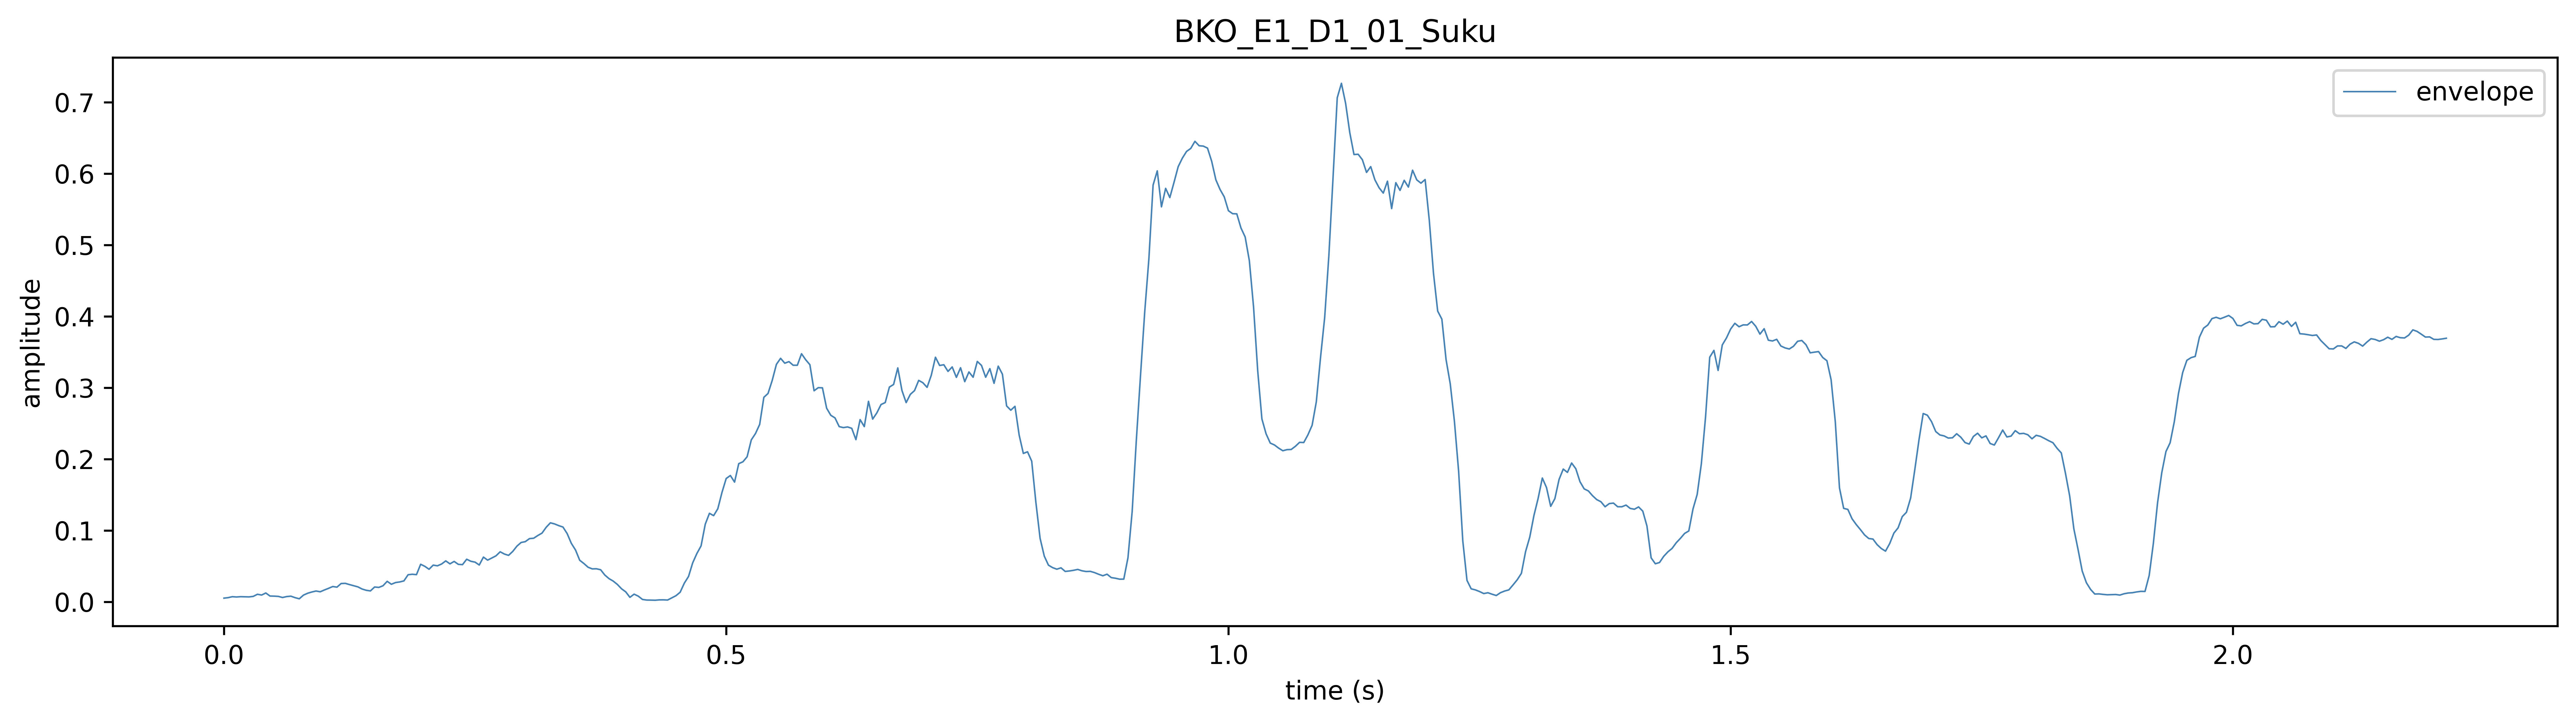

In [23]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt



envelope_df = pd.DataFrame(envelope_data)

plot_envelope_with_cycles(envelope_df.iloc[0])
plt.tight_layout()
plt.show()
